In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
#nome dos arquivos
arquivos = ["exemplos_01.png", "exemplos_02.png", "exemplos_03.png"]

#lista dos tempos de exposição 
tempos_exposicao = np.array([0.008, 0.016, 0.066], dtype=np.float32)

#lendo as imagens
lista_imagens = []
for nome in arquivos:
    imagem = cv2.imread(nome)
    if imagem is not None:
        lista_imagens.append(imagem)

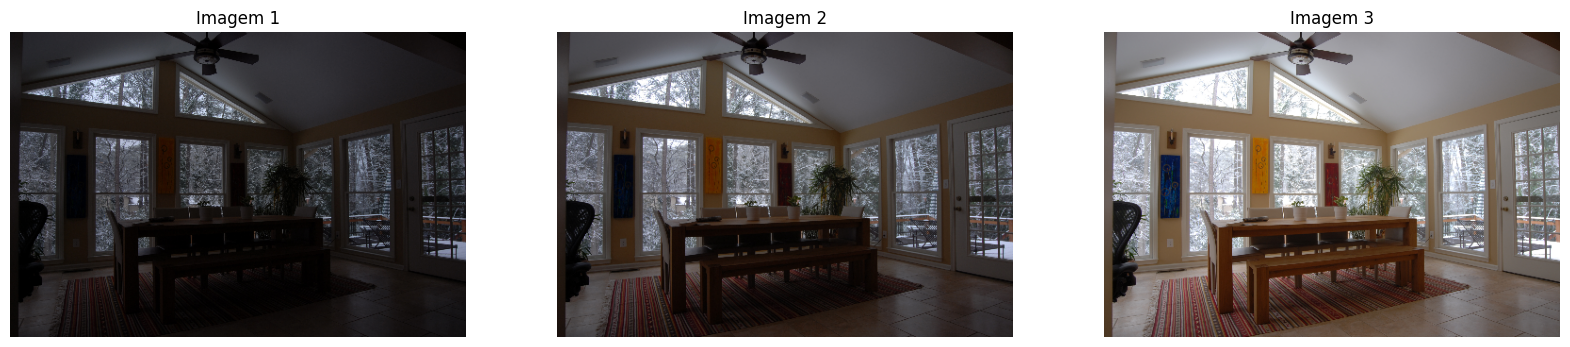

In [10]:
#plotando as imagens em ordem
plt.figure(figsize=(20, 10))
for i, img in enumerate(lista_imagens):
    plt.subplot(1, len(lista_imagens), i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Imagem {i+1}")

In [5]:
#criando o alinhador
alinhador = cv2.createAlignMTB()

#corrigindo pequenso movimentos
alinhador.process(lista_imagens, lista_imagens)

In [8]:
#estimando como a camera reage a luz
calibracao = cv2.createCalibrateDebevec()
resposta_camera = calibracao.process(lista_imagens, tempos_exposicao)

#mesclando as 3 imagens
fusao = cv2.createMergeDebevec()
imagem_hdr = fusao.process(lista_imagens, tempos_exposicao, resposta_camera)

[ WARN:0@192.550] global matrix_expressions.cpp:1333 assign OpenCV/MatExpr: processing of multi-channel arrays might be changed in the future: https://github.com/opencv/opencv/issues/16739
/tmp/ipykernel_11643/735973699.py:6: RuntimeWarning: invalid value encountered in cast
  imagem_final = np.clip(imagem_ldr * 255, 0, 255).astype('uint8')


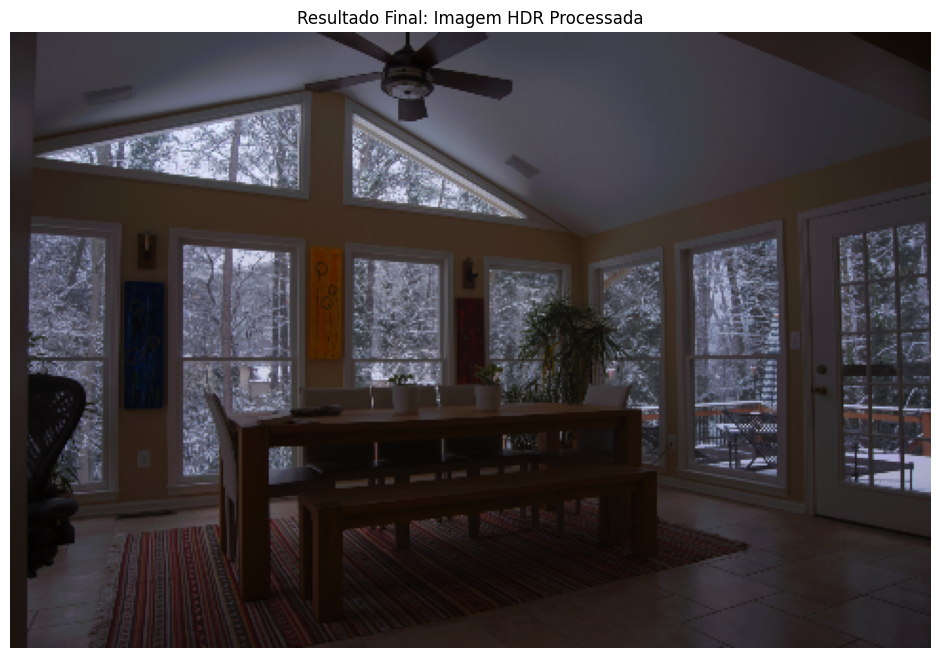

In [7]:
#metodo de Reinhard 
mapeamento_tons = cv2.createTonemapReinhard(1.5, 0, 0, 0)
imagem_ldr = mapeamento_tons.process(imagem_hdr)

#ajustando e convertendo para 8 bits
imagem_final = np.clip(imagem_ldr * 255, 0, 255).astype('uint8')

#salvando o resultado
cv2.imwrite("resultado_hdr.jpg", imagem_final)

#plotando o resultado
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(imagem_final, cv2.COLOR_BGR2RGB))
plt.title("Resultado Final: Imagem HDR Processada")
plt.axis('off')
plt.show()